IMPORT THƯ VIỆN

In [1]:
import os
import json
import warnings
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import pyodbc  

import lightgbm as lgb
from lightgbm import LGBMClassifier, early_stopping, log_evaluation
import optuna
import shap

from optuna import trial
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (classification_report, accuracy_score, precision_score, recall_score,
  f1_score, roc_auc_score,  average_precision_score,  confusion_matrix,  roc_curve, auc,
   ConfusionMatrixDisplay,PrecisionRecallDisplay, RocCurveDisplay)
from preprocessors import GroupMedianImputer, CategoricalCaster

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)


c:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


ĐỌC DỮ LIỆU TỪ SQL

In [7]:
conn = pyodbc.connect(
    "DRIVER={ODBC Driver 18 for SQL Server};"
    "SERVER=localhost;"  
    "DATABASE=NovaBank_CreditRisk;"
    "Trusted_Connection=yes;"
    "Encrypt=yes;"
    "TrustServerCertificate=yes;"
)

query = "SELECT * FROM dbo.vw_credit_risk_base"
df_raw = pd.read_sql(query, conn)

df_mln = df_raw.copy()

Select columns

In [8]:
#Target columns
target = "loan_status"

#numeric
numeric_cols = [
    "person_age",
    "person_income",
    "other_debt",
    "person_emp_length",
    "loan_amnt",
    "loan_int_rate",
    "loan_term_months",
    "loan_percent_income",
    "debt_to_income_ratio",
    "loan_to_income_ratio",
    "credit_utilization_ratio",
    "cb_person_cred_hist_length",
    "open_accounts",
    "past_delinquencies"
]

categorical_cols = [
    "person_home_ownership",
    "loan_intent",
    "employment_type",
    "education_level",
    "cb_person_default_on_file"
]

Train/Test Split

In [9]:
X = df_mln[numeric_cols + categorical_cols]
y = df_mln[target].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Training set : {X_train.shape}")
print(f"Testing set : {X_test.shape}")

Training set : (26064, 19)
Testing set : (6517, 19)


In [10]:
#Cap outliers
X_train["person_age"] = X_train["person_age"].clip(upper=80)
X_test["person_age"]  = X_test["person_age"].clip(upper=80)

X_train["person_emp_length"] = X_train["person_emp_length"].clip(upper=60)
X_test["person_emp_length"]  = X_test["person_emp_length"].clip(upper=60)

X_train["debt_to_income_ratio"] = X_train["debt_to_income_ratio"].clip(upper=1.0)
X_test["debt_to_income_ratio"]  = X_test["debt_to_income_ratio"].clip(upper=1.0)

print(X_train[["person_age", "person_emp_length", "debt_to_income_ratio"]].max())


#Missing Flags
X_train["emp_length_missing"] = X_train["person_emp_length"].isna().astype(int)
X_test["emp_length_missing"]  = X_test["person_emp_length"].isna().astype(int)

X_train["loan_int_rate_missing"] = X_train["loan_int_rate"].isna().astype(int)
X_test["loan_int_rate_missing"]  = X_test["loan_int_rate"].isna().astype(int)

print(X_train[["emp_length_missing", "loan_int_rate_missing"]].sum())
print(X_test[["emp_length_missing", "loan_int_rate_missing"]].sum())


#has prior default
X_train["has_prior_default"] = (  X_train["cb_person_default_on_file"]
    .map({"Y": 1, "N": 0}))

X_test["has_prior_default"] = ( X_test["cb_person_default_on_file"]
    .map({"Y": 1, "N": 0}))


#high loan burden flag
X_train["high_loan_burden_flag"] = (
    (X_train["loan_to_income_ratio"] > 0.30) | (X_train["debt_to_income_ratio"] > 0.40) ).astype(int)

X_test["high_loan_burden_flag"] = (
    (X_test["loan_to_income_ratio"] > 0.30) | (X_test["debt_to_income_ratio"] > 0.40) ).astype(int)


#Log1p
log1p_features = [
    "person_income",
    "other_debt",
]
for col in log1p_features:
      X_train[f"{col}_log"] = np.log1p(X_train[col])
      X_test[f"{col}_log"]  = np.log1p(X_test[col])


person_age              80.0
person_emp_length       60.0
debt_to_income_ratio     1.0
dtype: float64
emp_length_missing        738
loan_int_rate_missing    2501
dtype: int64
emp_length_missing       157
loan_int_rate_missing    615
dtype: int64


Set Feature LR

In [11]:
numeric_LR = [
    "person_age",
    "person_income_log",
    "other_debt_log",
    "person_emp_length",
    "loan_amnt",
    "loan_int_rate",
    "loan_term_months",
    "debt_to_income_ratio",
    "loan_to_income_ratio",
    "credit_utilization_ratio",
    "cb_person_cred_hist_length",
    "open_accounts",
    "past_delinquencies"
]

binary_LR = [
    "has_prior_default",
    "emp_length_missing",
    "loan_int_rate_missing",
    "high_loan_burden_flag"
]

categorical_LR = [
    "person_home_ownership",
    "loan_intent",
    "employment_type",
    "education_level"
]

Preprocessing And Logistics Regression Baseline

In [12]:
num_preprocessing_LR = Pipeline([
    ("scaler", RobustScaler())
])

cat_preprocessing_LR = Pipeline([
    ("onehot", OneHotEncoder( handle_unknown="ignore",drop="first" ) )
])

# Ghép các nhóm biến
preprocessing_LR = ColumnTransformer([
    ("numeric", num_preprocessing_LR,numeric_LR ),
    ("binary","passthrough", binary_LR ),
    ("categorical",cat_preprocessing_LR,categorical_LR )
])


Classification Report- TRAIN SET
              precision    recall  f1-score   support

           0       0.93      0.77      0.84     20378
           1       0.49      0.78      0.60      5686

    accuracy                           0.77     26064
   macro avg       0.71      0.78      0.72     26064
weighted avg       0.83      0.77      0.79     26064

ROC-AUC: 0.8580
PR-AUC : 0.6819
Classification Report- TEST SET
              precision    recall  f1-score   support

           0       0.93      0.77      0.84      5095
           1       0.49      0.79      0.60      1422

    accuracy                           0.77      6517
   macro avg       0.71      0.78      0.72      6517
weighted avg       0.83      0.77      0.79      6517

ROC-AUC: 0.8607
PR-AUC : 0.6931


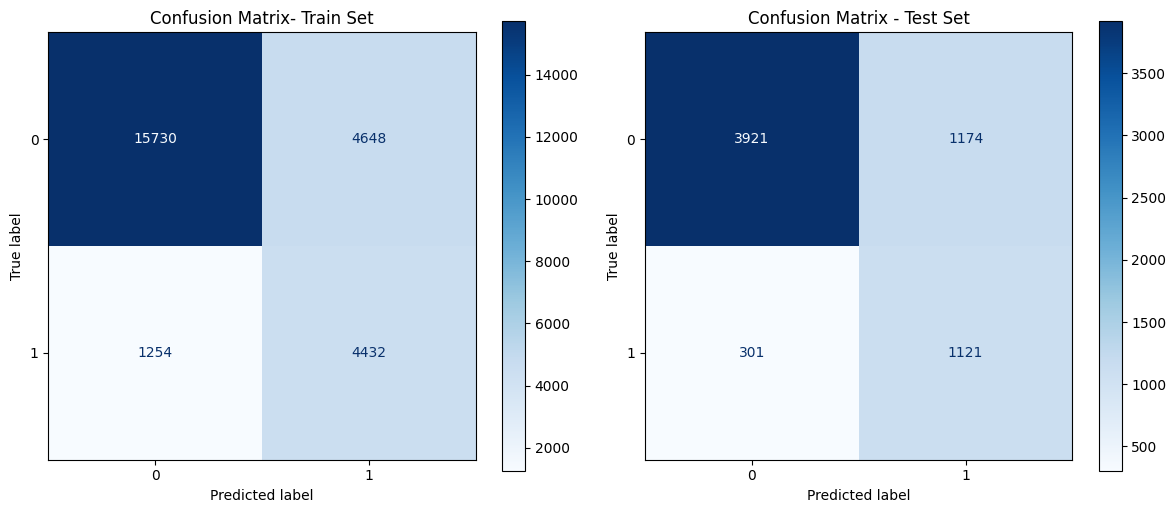

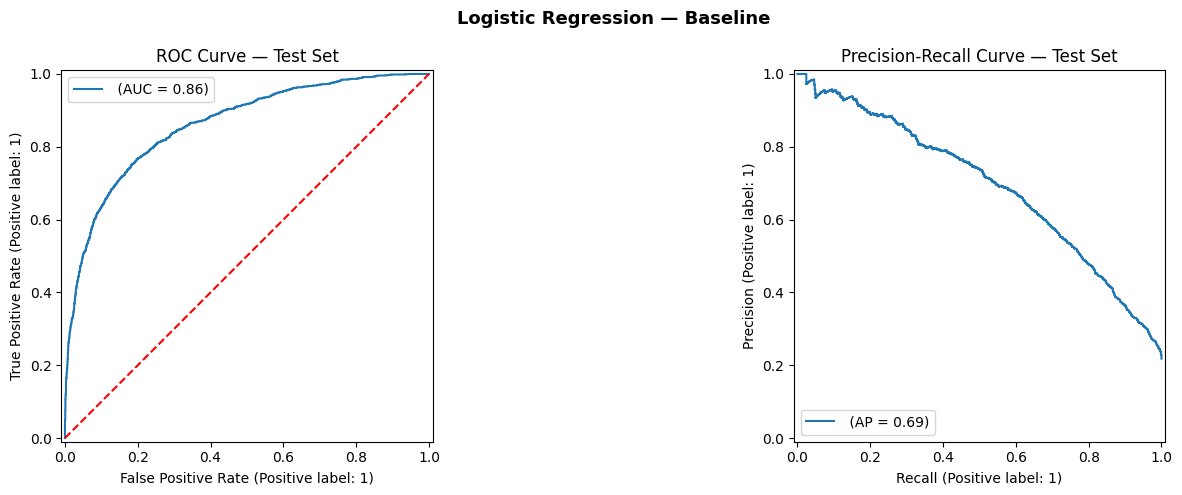

In [ ]:
LR_pipeline = Pipeline([
        ("group_imputer", GroupMedianImputer()),
        ("preprocessing", preprocessing_LR),
        ("model", LogisticRegression(
            max_iter=1000,  # số lần lặp tối đa 
            random_state=42,  # random state để tái lập kết quả
            class_weight="balanced",   # cân bằng trọng số lớp
            solver="saga",   # thuật toán tối ưu phù hợp với regularization
            l1_ratio=0.0,  # L2 regularization
            C=1.0  # regularization strength 
        ))
    ])
lr_model = LR_pipeline.fit(X_train, y_train)

# set ngưỡng dự đoán
threshold = 0.5

# dự đoán xác suất và nhãn
y_train_proba_lr = LR_pipeline.predict_proba(X_train)[:, 1]
y_test_proba_lr = LR_pipeline.predict_proba(X_test)[:, 1]

# dự đoán nhãn dựa trên ngưỡng
y_train_pred_lr = (y_train_proba_lr >= threshold).astype(int)
y_test_pred_lr = (y_test_proba_lr >= threshold).astype(int)

# classification report
print("Classification Report- TRAIN SET")
print(classification_report(y_train, y_train_pred_lr))
print(f"ROC-AUC: {roc_auc_score(y_train, y_train_proba_lr):.4f}")
print(f"PR-AUC: {average_precision_score(y_train, y_train_proba_lr):.4f}")

print("Classification Report- TEST SET")
print(classification_report(y_test, y_test_pred_lr))
print(f"ROC-AUC: {roc_auc_score(y_test, y_test_proba_lr):.4f}")
print(f"PR-AUC: {average_precision_score(y_test, y_test_proba_lr):.4f}")


# Confusion Matrix — Train và Test
matrix_train = confusion_matrix(y_train, y_train_pred_lr, labels=[0, 1])
matrix_test = confusion_matrix(y_test, y_test_pred_lr, labels=[0, 1])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

display_train = ConfusionMatrixDisplay(
    confusion_matrix=matrix_train,
    display_labels=[0, 1]
)

display_train.plot(
    ax=axes[0],
    values_format="d",
    colorbar=True,
    cmap="Blues"
)

axes[0].set_title("Confusion Matrix- Train Set")

display_test = ConfusionMatrixDisplay(
    confusion_matrix=matrix_test,
    display_labels=[0, 1]
)

display_test.plot(
    ax=axes[1],
    values_format="d",
    colorbar=True,
    cmap="Blues"
)
axes[1].set_title("Confusion Matrix - Test Set")

plt.tight_layout()
plt.show()


#  ROC Curve Predictions on Test set
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Logistic Regression — Baseline", fontsize=13, fontweight="bold")

RocCurveDisplay.from_predictions(
    y_test, y_test_proba_lr,
    name="",
    ax=axes[0]
)
axes[0].plot([0, 1], [0, 1], color="red", linestyle="--", )
axes[0].legend()
axes[0].set_title("ROC Curve — Test Set")

PrecisionRecallDisplay.from_predictions(
    y_test, y_test_proba_lr,
    name="",
    ax=axes[1]
)
axes[1].set_title("Precision-Recall Curve — Test Set")

plt.tight_layout()
plt.show()

set feature lighgbm

In [16]:
#set feature
numeric_LGBM = [
    "person_age",
    "person_income_log",
    "other_debt_log",
    "person_emp_length",
    "loan_amnt",
    "loan_int_rate",
    "loan_term_months",
    "loan_percent_income",
    "debt_to_income_ratio",
    "loan_to_income_ratio",
    "credit_utilization_ratio",
    "cb_person_cred_hist_length",
    "open_accounts",
    "has_prior_default",
    "past_delinquencies",
    "emp_length_missing",
    "loan_int_rate_missing",
    "high_loan_burden_flag"
]

categorical_LGBM = [
    "person_home_ownership",
    "loan_intent",
    "employment_type",
    "education_level"
]

Preprocessing and LighGBM Baseline

In [ ]:
X_train_LGBM = X_train[numeric_LGBM + categorical_LGBM].copy()
X_test_LGBM = X_test[numeric_LGBM + categorical_LGBM].copy()

# Scale pos weight
n_negative = (y_train == 0).sum()
n_positive = (y_train == 1).sum()
scale_pos_weight = n_negative / n_positive
print("Scale_pos_weight:", round(scale_pos_weight, 4))

Scale_pos_weight: 3.5839


Classification Report — TRAIN SET
              precision    recall  f1-score   support

           0       0.96      0.95      0.96     20378
           1       0.83      0.85      0.84      5686

    accuracy                           0.93     26064
   macro avg       0.90      0.90      0.90     26064
weighted avg       0.93      0.93      0.93     26064

ROC-AUC: 0.9735
PR-AUC: 0.9356

Classification Report — TEST SET
              precision    recall  f1-score   support

           0       0.94      0.94      0.94      5095
           1       0.79      0.78      0.78      1422

    accuracy                           0.91      6517
   macro avg       0.86      0.86      0.86      6517
weighted avg       0.91      0.91      0.91      6517

ROC-AUC: 0.9382
PR-AUC: 0.8850


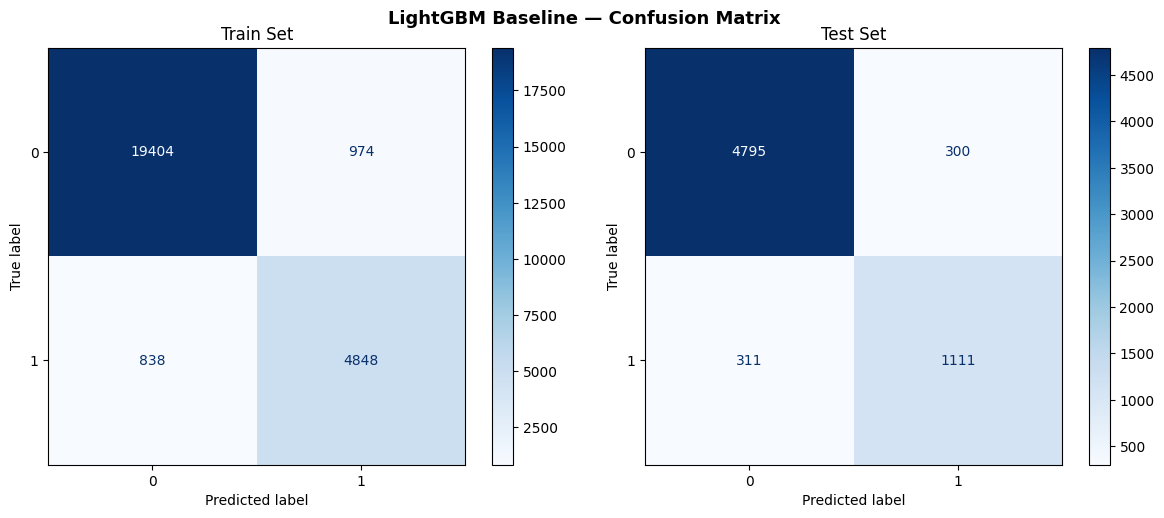

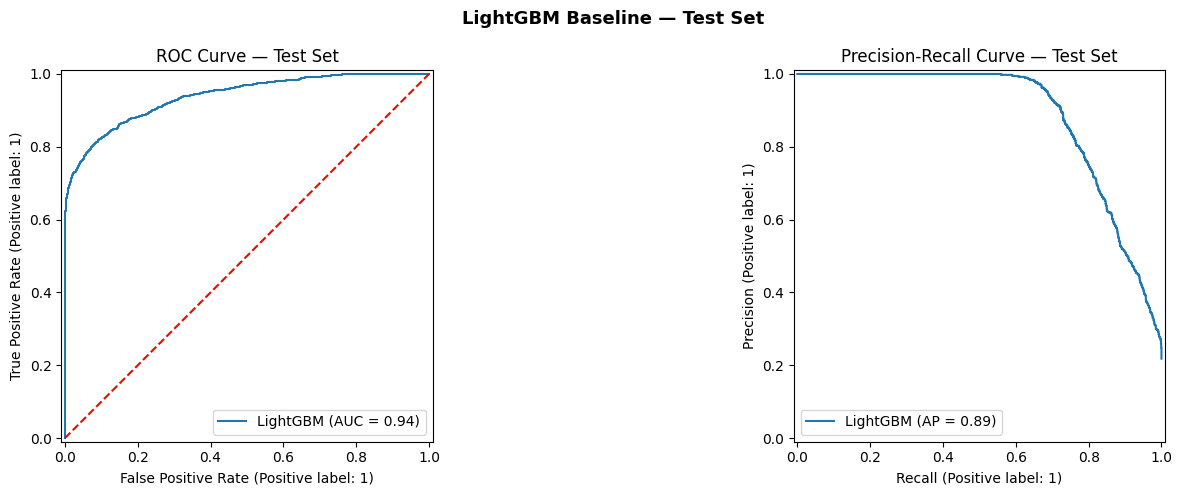

In [ ]:
LGBM_pipeline = Pipeline([
    ("group_imputer", GroupMedianImputer()),
    ("caster", CategoricalCaster(cols=categorical_LGBM)),
    ("model", LGBMClassifier(   
        objective = "binary",                     #bài toán phân loại nhị phân
        boosting_type = "gbdt",                   #tt thuật boosting decision tree
        n_estimators = 100,                       #số lượng cây trong mô hình
        scale_pos_weight = scale_pos_weight ,     #trọng số phạt cho lớp dương
        random_state = 42,                        #random state để tái lập kết quả
        n_jobs = -1,                              #số lượng CPU sử dụng
        verbose = -1,                             #tắt log 
    ))
])

lgbm_model = LGBM_pipeline.fit(X_train_LGBM, y_train)

# set  ngưỡng dự đoán
threshold = 0.5

# dự đoán xác suất về lớp 1
y_train_proba_lgbm = lgbm_model.predict_proba(X_train_LGBM)[:, 1]
y_test_proba_lgbm = lgbm_model.predict_proba(X_test_LGBM)[:, 1]

# dự đoán nhãn dựa trên ngưỡng
y_train_pred_lgbm = (y_train_proba_lgbm >= threshold).astype(int)
y_test_pred_lgbm = (y_test_proba_lgbm >= threshold).astype(int)

# Classification Report
print("Classification Report — TRAIN SET")
print(classification_report(y_train, y_train_pred_lgbm))
print(f"ROC-AUC: {roc_auc_score(y_train, y_train_proba_lgbm):.4f}")
print(f"PR-AUC: {average_precision_score(y_train, y_train_proba_lgbm):.4f}")

print("\nClassification Report — TEST SET")
print(classification_report(y_test, y_test_pred_lgbm))
print(f"ROC-AUC: {roc_auc_score(y_test, y_test_proba_lgbm):.4f}")
print(f"PR-AUC: {average_precision_score(y_test, y_test_proba_lgbm):.4f}")

# Confusion Matrix 
matrix_train = confusion_matrix(y_train, y_train_pred_lgbm, labels=[0, 1])
matrix_test = confusion_matrix(y_test,  y_test_pred_lgbm,  labels=[0, 1])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("LightGBM Baseline — Confusion Matrix", fontsize=13, fontweight="bold")

ConfusionMatrixDisplay(matrix_train, display_labels=["0", "1"]).plot(
    ax=axes[0], values_format="d", colorbar=True, cmap="Blues"
)
axes[0].set_title("Train Set")

ConfusionMatrixDisplay(matrix_test, display_labels=["0", "1"]).plot(
    ax=axes[1], values_format="d", colorbar=True, cmap="Blues"
)
axes[1].set_title("Test Set")

plt.tight_layout()
plt.show()

# ROC & PR Curves 
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("LightGBM Baseline — Test Set", fontsize=13, fontweight="bold")

RocCurveDisplay.from_predictions(
    y_test, y_test_proba_lgbm, name="LightGBM", ax=axes[0]
)
axes[0].plot([0, 1], [0, 1], color="red", linestyle="--", )
axes[0].set_title("ROC Curve — Test Set")
axes[0].legend()

PrecisionRecallDisplay.from_predictions(
    y_test, y_test_proba_lgbm, name="LightGBM", ax=axes[1]
)
axes[1].set_title("Precision-Recall Curve — Test Set")

plt.tight_layout()
plt.show()

Tinh chỉnh tham số

In [ ]:
SEED = 42
N_FOLDS = 5                 #số lượng fold trong cross-validation
N_TRIALS = 50               #số lượng thử nghiệm tối ưu hóa 

# khởi tạo kfold
kf = StratifiedKFold(
    n_splits=N_FOLDS,
    shuffle=True,
    random_state=SEED
)

def objective(trial):
    params = {
        "objective": "binary",                  # nhị phân
        "boosting_type": "gbdt",                # decision tree
        "random_state": SEED,
        "n_jobs": -1,                           # sử dụng tất cả CPU
        "verbosity": -1,                        # tắt log
        "metric": "average_precision",          # tối ưu hóa theo PR-AUC
        "n_estimators": 500,                    #số lượng cây 
        "scale_pos_weight": scale_pos_weight,   #trọng số phạt cho lớp dương

        # Tham số cần tối ưu
        "max_depth": trial.suggest_int("max_depth", 3, 6),                              #độ sâu tối đa của cây
        "num_leaves": trial.suggest_int("num_leaves", 5, 60),                           #số lá của cây quyết định
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.04, log=True),    #tốc độ học
        "min_child_samples": trial.suggest_int("min_child_samples", 120, 400),          #số mẫu tối thiểu trong một node lá
        "min_split_gain": trial.suggest_float("min_split_gain", 0.05, 1.0),             #gain tối thiểu để phân chia node
        "reg_alpha": trial.suggest_float("reg_alpha", 0.001, 10.00, log=True),          #tham số phạt trị tuyệt đối l1
        "reg_lambda": trial.suggest_float("reg_lambda", 0.005, 20.00, log=True),        #tham số phạt bình phương trọng số l2
        "feature_fraction": trial.suggest_float("feature_fraction", 0.6, 0.8),          #tỷ lệ cột trên mỗi cây
        "bagging_fraction": trial.suggest_float("bagging_fraction", 0.6, 0.8)           #tỷ lệ số mẫu trên mỗi cây
    }


    pr_auc_scores = []

    # đánh giá params trên 5 folds
    for fold, (train_idx, val_idx) in enumerate(
        kf.split(X_train_LGBM, y_train), start=1):

        # chia fold
        X_fold_train = X_train_LGBM.iloc[train_idx].copy()
        X_fold_val = X_train_LGBM.iloc[val_idx].copy()

        y_fold_train = y_train.iloc[train_idx]
        y_fold_val = y_train.iloc[val_idx]
    
       # Pipeline 
        pipeline = Pipeline([
            ("imputer", GroupMedianImputer()),
            ("caster",  CategoricalCaster(cols=categorical_LGBM)),
            ("model",   LGBMClassifier(**params))
        ])

        # train lightgbm
        pipeline.fit(
            X_fold_train, y_fold_train,
            model__categorical_feature=categorical_LGBM,
            model__callbacks=[log_evaluation(0)])

        y_val_proba = pipeline.predict_proba(X_fold_val)[:, 1]
        fold_pr_auc = average_precision_score(y_fold_val, y_val_proba)
        pr_auc_scores.append(fold_pr_auc)

    return np.mean(pr_auc_scores)

run optuna

In [13]:
import warnings
import optuna
warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Tối ưu hóa tham số với Optuna
study = optuna.create_study(
    direction="maximize",  
    sampler=optuna.samplers.TPESampler(seed=SEED) 
)
study.optimize(
    objective,
    n_trials=N_TRIALS,
    show_progress_bar=True
)

print("Best PR-AUC: ")
print(round(study.best_value, 4))
print("Best params: ")
for key, value in study.best_params.items():
    print(f"{key}: {value}")

Best trial: 45. Best value: 0.875642: 100%|██████████| 50/50 [01:46<00:00,  2.13s/it]

Best PR-AUC: 
0.8756
Best params: 
max_depth: 6
num_leaves: 22
learning_rate: 0.03445410778388481
min_child_samples: 163
min_split_gain: 0.20481727100512248
reg_alpha: 0.004248585495697904
reg_lambda: 0.1616793566004042
feature_fraction: 0.6226378702912142
bagging_fraction: 0.7069592522652414


best iteration

In [ ]:
best_params = study.best_params.copy()
X_es_train, X_es_val, y_es_train, y_es_val = train_test_split(
    X_train_LGBM, y_train,
    test_size=0.1,
    random_state=SEED,
    stratify=y_train
)

# preprocessing 
preprocessor = Pipeline([
    ("imputer", GroupMedianImputer()),
    ("caster", CategoricalCaster(cols=categorical_LGBM)),])
    
X_es_train_p = preprocessor.fit_transform(X_es_train)
X_es_val_p = preprocessor.transform(X_es_val)

# Early stopping tìm số cây phù hợp
lgbm_es = LGBMClassifier(
    **best_params,
    objective = "binary",
    n_estimators = 1000,  
    scale_pos_weight = scale_pos_weight,
    random_state = SEED,
    n_jobs = -1,
    verbosity = -1
)

lgbm_es.fit(
    X_es_train_p,
    y_es_train,
    eval_set=[(X_es_val_p, y_es_val)],
    eval_metric="average_precision",
    categorical_feature=categorical_LGBM,
    callbacks=[
        early_stopping(
            stopping_rounds=100,
            verbose=True
        ),
        log_evaluation(100)
    ])

best_n = lgbm_es.best_iteration_

print(f"Best iteration: {best_n}")

Training until validation scores don't improve for 100 rounds
[100]	valid_0's average_precision: 0.849382	valid_0's binary_logloss: 0.332295
[200]	valid_0's average_precision: 0.860576	valid_0's binary_logloss: 0.305558
[300]	valid_0's average_precision: 0.867909	valid_0's binary_logloss: 0.291947
[400]	valid_0's average_precision: 0.871939	valid_0's binary_logloss: 0.283744
[500]	valid_0's average_precision: 0.874508	valid_0's binary_logloss: 0.276963
[600]	valid_0's average_precision: 0.87676	valid_0's binary_logloss: 0.270505
[700]	valid_0's average_precision: 0.877843	valid_0's binary_logloss: 0.265794
[800]	valid_0's average_precision: 0.878081	valid_0's binary_logloss: 0.26215
[900]	valid_0's average_precision: 0.877813	valid_0's binary_logloss: 0.259724
Early stopping, best iteration is:
[816]	valid_0's average_precision: 0.878514	valid_0's binary_logloss: 0.261381
Best iteration: 816


retrain full

In [15]:
lgbm_pipeline = Pipeline([
    ("imputer", GroupMedianImputer()),
    ("caster", CategoricalCaster(cols=categorical_LGBM)),
    ("model", LGBMClassifier(
        **best_params,
        objective = "binary",
        n_estimators = best_n,
        scale_pos_weight = scale_pos_weight,
        random_state  = SEED,
        n_jobs = -1,
        verbosity = -1
    ))
])

lgbm_pipeline.fit(
    X_train_LGBM,
    y_train,
    model__categorical_feature=categorical_LGBM
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputer', ...), ('caster', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,cols,"['person_home_ownership', 'loan_intent', ...]"
,boosting_type,'gbdt'
,num_leaves,22
,max_depth,6
,learning_rate,0.03445410778388481
,n_estimators,816
,subsample_for_bin,200000


Classification Report — TRAIN SET
              precision    recall  f1-score   support

           0       0.96      0.95      0.96     20378
           1       0.83      0.87      0.85      5686

    accuracy                           0.93     26064
   macro avg       0.90      0.91      0.90     26064
weighted avg       0.93      0.93      0.93     26064

ROC-AUC: 0.9781
PR-AUC: 0.9438

Classification Report — TEST SET
              precision    recall  f1-score   support

           0       0.94      0.94      0.94      5095
           1       0.78      0.79      0.79      1422

    accuracy                           0.91      6517
   macro avg       0.86      0.87      0.86      6517
weighted avg       0.91      0.91      0.91      6517

ROC-AUC: 0.9431
PR-AUC: 0.8916


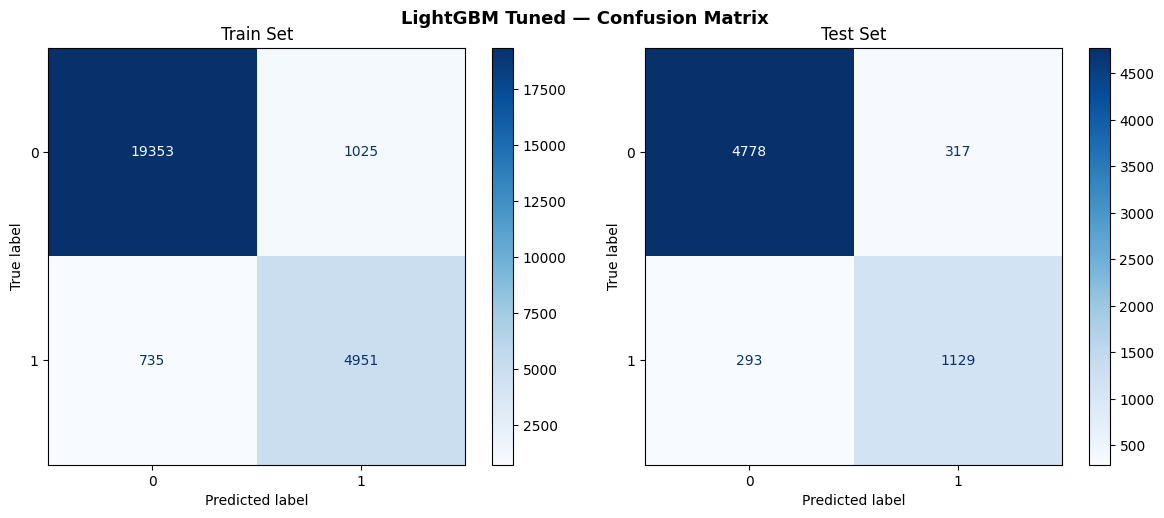

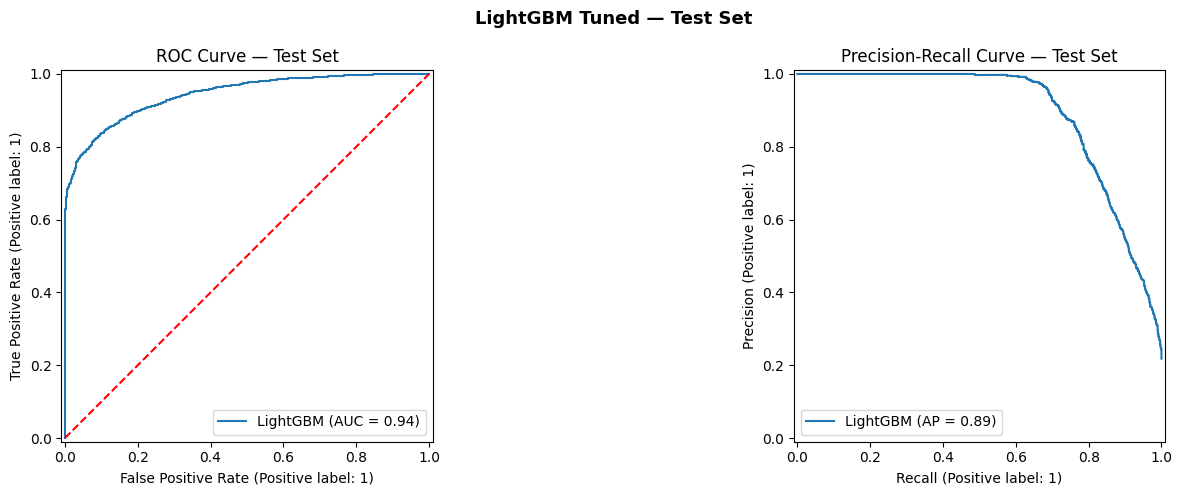

In [16]:
#set ngưỡng 
threshold = 0.5

y_train_proba_tuned = lgbm_pipeline.predict_proba(X_train_LGBM)[:, 1]
y_test_proba_tuned = lgbm_pipeline.predict_proba( X_test_LGBM )[:, 1]

y_train_pred_tuned = (y_train_proba_tuned >= threshold).astype(int)
y_test_pred_tuned = (y_test_proba_tuned >= threshold).astype(int)

# Classification Report
print("Classification Report — TRAIN SET")
print(classification_report(y_train, y_train_pred_tuned,))
print(f"ROC-AUC: {roc_auc_score(y_train, y_train_proba_tuned):.4f}")
print(f"PR-AUC: {average_precision_score(y_train, y_train_proba_tuned):.4f}")

print("\nClassification Report — TEST SET")
print(classification_report(y_test, y_test_pred_tuned,))
print(f"ROC-AUC: {roc_auc_score(y_test, y_test_proba_tuned):.4f}")
print(f"PR-AUC: {average_precision_score(y_test, y_test_proba_tuned):.4f}")

# Confusion Matrix 
matrix_train = confusion_matrix(y_train, y_train_pred_tuned, labels=[0, 1])
matrix_test = confusion_matrix(y_test,  y_test_pred_tuned,  labels=[0, 1])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("LightGBM Tuned — Confusion Matrix", fontsize=13, fontweight="bold")

ConfusionMatrixDisplay(matrix_train, display_labels=["0", "1"]).plot(
    ax=axes[0], values_format="d", colorbar=True, cmap="Blues")
axes[0].set_title("Train Set")

ConfusionMatrixDisplay(matrix_test, display_labels=["0", "1"]).plot(
    ax=axes[1], values_format="d", colorbar=True, cmap="Blues")
axes[1].set_title("Test Set")

plt.tight_layout()
plt.show()

# ROC & PR Curves 
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("LightGBM Tuned — Test Set", fontsize=13, fontweight="bold")

RocCurveDisplay.from_predictions(
    y_test, y_test_proba_tuned, name="LightGBM", ax=axes[0])
axes[0].plot([0, 1], [0, 1], color="red", linestyle="--", )
axes[0].set_title("ROC Curve — Test Set")
axes[0].legend()

PrecisionRecallDisplay.from_predictions(
    y_test, y_test_proba_tuned, name="LightGBM", ax=axes[1])
axes[1].set_title("Precision-Recall Curve — Test Set")

plt.tight_layout()
plt.show()

So sánh các mô hình

In [17]:
model = {
    "Logistic Regression": (y_test, y_test_pred_lr, y_test_proba_lr),
    "LightGBM baseline": (y_test, y_test_pred_lgbm, y_test_proba_lgbm),
    "LightGBM tuned": (y_test, y_test_pred_tuned, y_test_proba_tuned),
}
rows = []
for model_name, (y_true, y_pred, y_proba) in model.items():
    rows.append({
        "Model": model_name,
        "F1-Score": f1_score(y_true, y_pred),
        "ROC-AUC": roc_auc_score(y_true, y_proba),
        "PR-AUC": average_precision_score(y_true, y_proba),
    })
print(pd.DataFrame(rows).set_index("Model").round(4))

                     F1-Score  ROC-AUC  PR-AUC
Model                                         
Logistic Regression    0.6032   0.8607  0.6931
LightGBM baseline      0.7843   0.9382  0.8850
LightGBM tuned         0.7873   0.9431  0.8916


Shap feature important

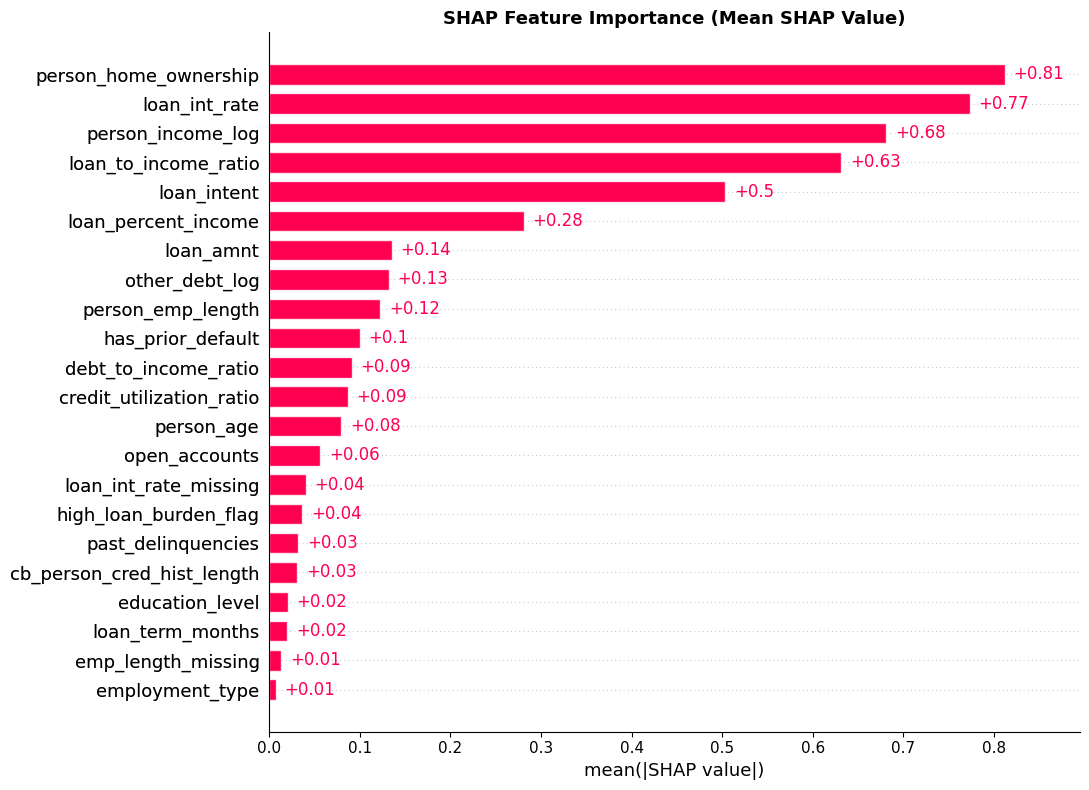

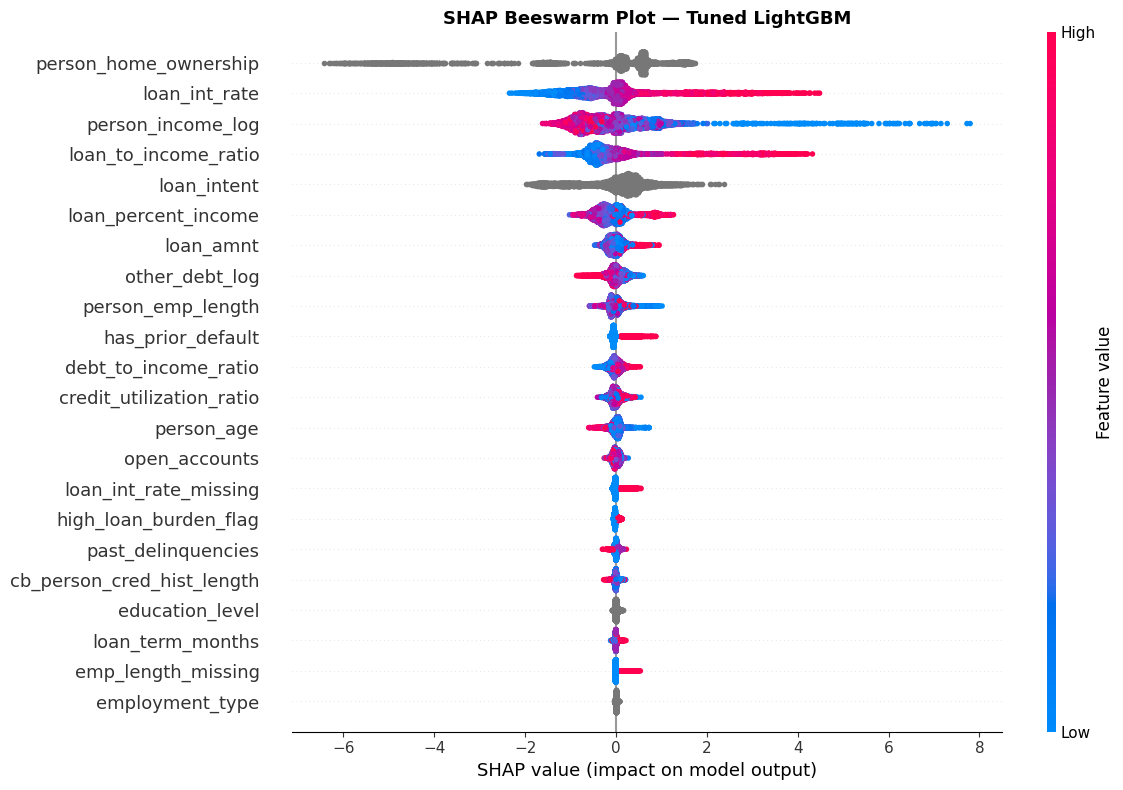

In [18]:
import shap
import matplotlib.pyplot as plt

X_test_shap = lgbm_pipeline[:-1].transform(X_test_LGBM)

# Lấy model từ pipeline để truyền vào SHAP
lgbm_model = lgbm_pipeline.named_steps["model"]
explainer = shap.TreeExplainer(lgbm_model)
shap_values = explainer(X_test_shap)

#  Bar plot 
shap.plots.bar(shap_values, max_display=len(X_test_shap.columns), show=False)
plt.gcf().set_size_inches(11, 8)
plt.title("SHAP Feature Importance (Mean SHAP Value)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

#  Beeswarm plot 
shap.plots.beeswarm(shap_values, max_display=len(X_test_shap.columns), show=False)
plt.gcf().set_size_inches(12, 8)
plt.title("SHAP Beeswarm Plot — Tuned LightGBM", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

In [19]:
shap_value_df = pd.DataFrame(
    shap_values.values,
    columns=X_test_shap.columns,
    index=X_test_shap.index
)

categorical_features = [
    "person_home_ownership",
    "loan_intent"
  ]

for col in categorical_features:
    category_table = (
        pd.DataFrame({
            col: X_test_shap[col],
            "SHAP Value": shap_value_df[col]
        }).groupby(col, observed=True)["SHAP Value"].agg(Mean_SHAP="mean",Count="count").sort_values(by="Mean_SHAP",ascending=False))
    print(category_table.round(4).to_string())

                       Mean_SHAP  Count
person_home_ownership                  
RENT                      0.7081   3248
OTHER                     0.1524     18
MORTGAGE                 -0.0459   2757
OWN                      -4.7174    494
                   Mean_SHAP  Count
loan_intent                        
HOMEIMPROVEMENT       0.7015    728
DEBTCONSOLIDATION     0.4870   1047
MEDICAL               0.3574   1177
PERSONAL              0.0994   1143
EDUCATION            -0.1074   1275
VENTURE              -1.2360   1147


PHÂN TÍCH LỖI MÔ HÌNH  

In [38]:
analysis_df = X_test.copy()
analysis_df['actual'] = y_test.values
analysis_df['pred'] = y_test_pred_tuned

# Phân loại nhóm dự đoán
fn_df = analysis_df[(analysis_df['actual'] == 1) & (analysis_df['pred'] == 0)]
tn_df = analysis_df[(analysis_df['actual'] == 0) & (analysis_df['pred'] == 0)]
fp_df = analysis_df[(analysis_df['actual'] == 0) & (analysis_df['pred'] == 1)]
tp_df = analysis_df[(analysis_df['actual'] == 1) & (analysis_df['pred'] == 1)]

# Số lượng các nhóm tổng quan
print(f"FN (False Negative): {len(fn_df)} / TN (True Negative): {len(tn_df)}")
print(f"FP (False Positive): {len(fp_df)} / TP (True Positive): {len(tp_df)}")

tn_fp = pd.DataFrame({
    'TN (True Negative)': [
        tn_df['person_income'].median(),
        tn_df['loan_amnt'].median(),
        tn_df['loan_int_rate'].mean()
    ],
    'FP (False Positive)': [
        fp_df['person_income'].median(),
        fp_df['loan_amnt'].median(),
        fp_df['loan_int_rate'].mean()
    ]
}, index=['Trung vị thu nhập', 'Trung vị khoản vay', 'Trung bình lãi suất']).round(2)
print(tn_fp)

fn_tp = pd.DataFrame({
     'TP (True Positive)': [
        tp_df['person_income'].median(),
        tp_df['loan_amnt'].median(),
        tp_df['loan_int_rate'].mean()
    ],
    'FN (False Negative)': [
        fn_df['person_income'].median(),
        fn_df['loan_amnt'].median(),
        fn_df['loan_int_rate'].mean()
    ]
}, index=['Trung vị thu nhập', 'Trung vị khoản vay', 'Trung bình lãi suất']).round(2)
print(fn_tp)

# Tỷ lệ và số lượng duyệt đúng/từ chối nhầm theo từng phân khúc Mục đích vay của Khách tốt (TN vs FP)
print("\nTN vs FP với tỷ lệ theo mục đích vay")
total_intent_p = tn_df['loan_intent'].value_counts() + fp_df['loan_intent'].value_counts()
intent_tn_pct = (tn_df['loan_intent'].value_counts() / total_intent_p * 100).round(2)
intent_fp_pct = (fp_df['loan_intent'].value_counts() / total_intent_p * 100).round(2)
intent = pd.DataFrame({
    'Số lượng TN': tn_df['loan_intent'].value_counts(),
    'Số lượng FP': fp_df['loan_intent'].value_counts(),
    'TN (%)': intent_tn_pct,
    'FP (%)': intent_fp_pct
}).fillna(0)
print(intent)

print("\nTN vs FP với tỷ lệ theo tình trạng nhà ở")
total_home_p = tn_df['person_home_ownership'].value_counts() + fp_df['person_home_ownership'].value_counts()
home_tn_pct = (tn_df['person_home_ownership'].value_counts() / total_home_p * 100).round(2)
home_fp_pct = (fp_df['person_home_ownership'].value_counts() / total_home_p * 100).round(2)
home = pd.DataFrame({
    'Số lượng TN': tn_df['person_home_ownership'].value_counts(),
    'Số lượng FP': fp_df['person_home_ownership'].value_counts(),
    'TN (%)': home_tn_pct,
    'FP (%)': home_fp_pct
}).fillna(0)
print(home)


# Tỷ lệ và số lượng bỏ sót/chặn đúng theo từng phân khúc Mục đích vay của Khách xấu (FN vs TP)
print("\nFN vs TP với tỷ lệ theo mục đích vay")
total_intent_n = tp_df['loan_intent'].value_counts() + fn_df['loan_intent'].value_counts()
intent_tp_pct = (tp_df['loan_intent'].value_counts() / total_intent_n * 100).round(2)
intent_fn_pct = (fn_df['loan_intent'].value_counts() / total_intent_n * 100).round(2)

intent2 = pd.DataFrame({
    'Số lượng TP': tp_df['loan_intent'].value_counts(),
    'Số lượng FN': fn_df['loan_intent'].value_counts(),
    'TP (%)': intent_tp_pct,
    'FN (%)': intent_fn_pct
}).fillna(0)
print(intent2)

print("\nFN vs TP với tỷ lệ theo tình trạng nhà ở")
total_home_n = tp_df['person_home_ownership'].value_counts() + fn_df['person_home_ownership'].value_counts()
home_tp_pct = (tp_df['person_home_ownership'].value_counts() / total_home_n * 100).round(2)
home_fn_pct = (fn_df['person_home_ownership'].value_counts() / total_home_n * 100).round(2)

home2 = pd.DataFrame({
    'Số lượng TP': tp_df['person_home_ownership'].value_counts(),
    'Số lượng FN': fn_df['person_home_ownership'].value_counts(),
    'TP (%)': home_tp_pct,
    'FN (%)': home_fn_pct
}).fillna(0)
print(home2)


FN (False Negative): 293 / TN (True Negative): 4778
FP (False Positive): 317 / TP (True Positive): 1129
                     TN (True Negative)  FP (False Positive)
Trung vị thu nhập              60000.00             45000.00
Trung vị khoản vay              8000.00              7800.00
Trung bình lãi suất               10.15                14.03
                     TP (True Positive)  FN (False Negative)
Trung vị thu nhập              39000.00             49000.00
Trung vị khoản vay             10000.00              7500.00
Trung bình lãi suất               13.67                11.05

TN vs FP với tỷ lệ theo mục đích vay
                   Số lượng TN  Số lượng FP  TN (%)  FP (%)
loan_intent                                                
DEBTCONSOLIDATION          648           68   90.50    9.50
EDUCATION                 1011           57   94.66    5.34
HOMEIMPROVEMENT            482           53   90.09    9.91
MEDICAL                    816           52   94.01    5.99
PERSONAL  

KIỂM ĐỊNH MÔ HÌNH   
  Đo lường mức độ tách biệt tổng thể giữa khách hàng Tốt và Xấu trên toàn bộ đường cong.  
  Đo lường khoảng cách phân tách rủi ro lớn nhất tại một điểm cắt (Cut-off point) cụ thể.

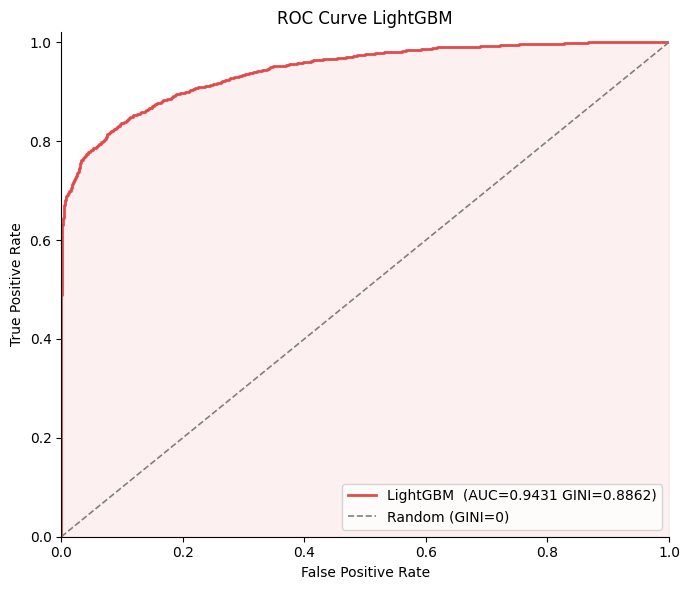


KS = 73.0800  (tại Decile 2)

 Decile   N  Bad  Good  Bad Rate%  Cum Bad%  Cum Good%    KS
      1 652  652     0      100.0     45.85       0.00 45.85
      2 652  445   207       68.3     77.14       4.06 73.08
      3 651  131   520       20.1     86.36      14.27 72.09
      4 652   75   577       11.5     91.63      25.59 66.04
      5 651   54   597        8.3     95.43      37.31 58.12
      6 652   28   624        4.3     97.40      49.56 47.84
      7 652   22   630        3.4     98.95      61.92 37.03
      8 651    6   645        0.9     99.37      74.58 24.79
      9 652    9   643        1.4    100.00      87.20 12.80
     10 652    0   652        0.0    100.00     100.00  0.00


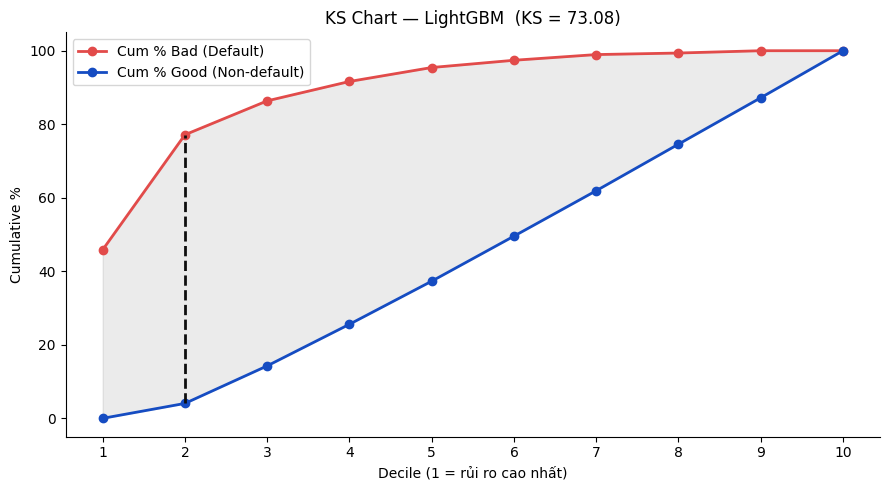

In [78]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

#gini
fpr, tpr, _ = roc_curve(y_test, y_test_proba_tuned)
roc_auc  = auc(fpr, tpr)
gini  = 2 * roc_auc - 1

fig, ax = plt.subplots(figsize=(7, 6))

# vẽ đường ROC của mô hình 
ax.plot(fpr, tpr, color="#E24B4A", lw=2, label=f"LightGBM  (AUC={roc_auc:.4f} GINI={gini:.4f})")
ax.plot([0,1], [0,1], color="gray", lw=1.2, linestyle="--", label="Random (GINI=0)")
ax.fill_between(fpr, tpr, alpha=0.08, color="#E24B4A")

ax.set(xlabel="False Positive Rate", ylabel="True Positive Rate",
       title="ROC Curve LightGBM", xlim=[0,1], ylim=[0,1.02])
ax.legend(fontsize=10)
ax.spines[["top","right"]].set_visible(False)

plt.tight_layout()
plt.show()

# decile
# tạo bảng dữ liệu xác suất và nhãn thực tế
df_ks = pd.DataFrame({"proba": y_test_proba_tuned, "actual": y_test.values})
# Chia 10 deciles 
df_ks["decile"] = 9 - pd.qcut(df_ks["proba"], q=10, labels=False, duplicates="drop") + 1

# số lượng hồ sơ 
df_dec = df_ks.groupby("decile", observed=True).agg(
    N = ("actual", "count"),
    Bad = ("actual", "sum")
).reset_index()

# Đổi lại tên cột
df_dec.columns = ["Decile", "N", "Bad"]
df_dec["Good"] = df_dec["N"] - df_dec["Bad"]
df_dec["Bad Rate%"] = (df_dec["Bad"] / df_dec["N"] * 100).round(1)

# Tính tổng số nợ xấu và nợ tốt
total_bad  = df_dec["Bad"].sum()
total_good = df_dec["Good"].sum()

# tính % lũy kế của Bad, Good và chỉ số KS từng decile
df_dec["Cum Bad%"] = (df_dec["Bad"].cumsum() / total_bad  * 100).round(2)
df_dec["Cum Good%"] = (df_dec["Good"].cumsum() / total_good * 100).round(2)
df_dec["KS"] = (df_dec["Cum Bad%"] - df_dec["Cum Good%"]).round(2)

# Tìm giá trị KS lớn nhất và vị trí Decile tương ứng
ks_max = df_dec["KS"].max()
ks_dec = df_dec.loc[df_dec["KS"].idxmax(), "Decile"]

print(f"\nKS = {ks_max:.4f}  (tại Decile {ks_dec})\n")
print(df_dec.to_string(index=False))

#ks chart
fig, ax = plt.subplots(figsize=(9, 5))

# Vẽ đường cong Bad và Good
ax.plot(df_dec["Decile"], df_dec["Cum Bad%"],  "o-", color="#E24B4A", lw=2, label="Cum % Bad (Default)")
ax.plot(df_dec["Decile"], df_dec["Cum Good%"], "o-", color="#154CC2", lw=2, label="Cum % Good (Non-default)")
ks_row = df_dec[df_dec["Decile"] == ks_dec].iloc[0]
ax.vlines(ks_dec, ks_row["Cum Good%"], ks_row["Cum Bad%"], color="#0E0E0E", lw=2, linestyle="--")

# Tô bóng khoảng cách giữa 2 đường cong
ax.fill_between(df_dec["Decile"], df_dec["Cum Bad%"], df_dec["Cum Good%"], alpha=0.08, color="#000000")

ax.set(xlabel="Decile (1 = rủi ro cao nhất)", ylabel="Cumulative %",
       title=f"KS Chart — LightGBM  (KS = {ks_max:.2f})", xticks=range(1, 11))
ax.legend(fontsize=10)
ax.spines[["top","right"]].set_visible(False)

plt.tight_layout()
plt.show()


 Credit score, band

In [ ]:
import numpy as np
import pandas as pd

#chuyển đổi prod thành score odds
def prob_to_score(prob, base_score=600, pdo=20):
   
    prob = np.clip(prob, 1e-6, 1 - 1e-6)   # tránh log(0)
    factor = pdo / np.log(2)
    offset = base_score - factor * np.log(1)  # log(1) = 0  offset = base_score 
    odds = (1 - prob) / prob                # odds = p(non-default)/p(default)
    score = offset + factor * np.log(odds)   # score tăng khi odds tăng 

    return np.clip(score, 300, 850).astype(int)

# tính score
y_prob = lgbm_pipeline.predict_proba(X_test_LGBM)[:, 1]
credit_score = prob_to_score(y_prob)

print("Score thấp nhất:", credit_score.min())
print("Score cao nhất:", credit_score.max())

# tính điểm min, max tại 10 decile
df_decile = pd.DataFrame({"credit_score": credit_score})
df_decile["decile"] = pd.qcut(df_decile["credit_score"], q=10, labels=False, duplicates="drop") + 1
decile_table = (
    df_decile.groupby("decile", observed=True)["credit_score"]
    .agg(score_min="min", score_max="max")
    .reset_index())

print(decile_table.to_string(index=False))

Score thấp nhất: 312
Score cao nhất: 850
 decile  score_min  score_max
      1        312        498
      2        499        593
      3        594        616
      4        617        631
      5        632        643
      6        644        655
      7        656        668
      8        669        687
      9        688        726
     10        727        850


In [ ]:
import pandas as pd

high_risk = 616
medium_risk = 643

def assign_risk_band(score):
    if score <= high_risk: return "High"
    elif score <= medium_risk: return "Medium"
    else:return "Low"

def assign_action(score):
    if score <= high_risk:return "Reject"
    elif score <= medium_risk:return "Review"
    else: return "Approve"

#tạo df rủi ro
df_result = pd.DataFrame({
    "prob_default": y_prob.round(4),
    "credit_score": credit_score,
    "risk_band": [assign_risk_band(s) for s in credit_score],
    "action": [assign_action(s)    for s in credit_score],
    "true_label": y_test.values
})

# Gom nhóm thống kê theo nhóm rủi ro 
band_summary = df_result.groupby("risk_band", observed=False).agg({
    "true_label": ["count", "sum"],
    "credit_score": "mean",
    "prob_default": "mean"})
band_summary.columns = ["total", "n_default", "avg_score", "avg_prob"]
band_summary = band_summary.reset_index()

# Tính tỷ lệ nợ xấu từng nhóm
band_summary["default_rate%"] = (band_summary["n_default"] / band_summary["total"] * 100).round(2)

# sắp xếp theo mức rủi ro
band_order = ["High", "Medium", "Low"]
band_summary = band_summary.set_index("risk_band").loc[band_order].reset_index()
print(band_summary.to_string(index=False))


risk_band  total  n_default  avg_score  avg_prob  default_rate%
     High   1970       1232 536.886802  0.737418          62.54
   Medium   1302        126 630.848694  0.255398           9.68
      Low   3245         64 694.478891  0.070372           1.97


Lưu model

In [96]:
import joblib, json, os
os.makedirs("artifacts", exist_ok=True)

#Lưu pipeline 
joblib.dump(lgbm_pipeline, "artifacts/lgbm_pipeline.pkl")
categories_map = lgbm_pipeline.named_steps["caster"].categories_

# Lưu metadata 
metadata = {
    "threshold"  : 0.5,
    "features"   : numeric_LGBM + categorical_LGBM,
    "categorical_categories": categories_map,
    "score_min"  : 300,
    "score_max"  : 850,
    "pdo"        : 20,
    "base_score" : 600,
    "band_config": {
        "high_risk_max"  : 616,
        "medium_risk_max": 643
    },
    "model_version": "lgbm_tuned"
}

with open("artifacts/metadata.json", "w") as f:
    json.dump(metadata, f, indent=4)